# Error models: there is a right way and many wrong ways

We are going to fit the same data with the same model six times over, changing only one thing: the model covariance we use. 

Along the way we infer a noise level the experiment never reported, add a correlated systematic, and get it wrong on purpose so we can  see what the classic mistake does to the answer.

Recipes: 2, 4, 19

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## Where a $\chi^2$ comes from

Every fit assumes a likelihood, whether or not anyone writes it down. Counting events in a bin - e.g. counts in a detector - gives a [binomial](https://en.wikipedia.org/wiki/Binomial_distribution), which, in the limit of small bins, gives a [Poisson](https://en.wikipedia.org/wiki/Poisson_distribution), which, in the further limit of many counts — a [normal](https://en.wikipedia.org/wiki/Normal_distribution). If the bins are independent, that is a diagonal
[multivariate normal](https://en.wikipedia.org/wiki/Multivariate_normal_distribution), and the logarithm of such a likelihood iss $-\chi^2/2$. This result relies on assumptions: that the points are independent, that our model can reproduce the truth exactly, and that the errors are what the experiment says they are.  

When the points are not independent, we generalize to a multivariate normal with non-diagonal *covariance*,

$$\log p(\mathbf{y}\mid\theta) = -\tfrac12 (\mathbf{y}-\mathbf{y}_m)^\mathsf{T}
\Sigma^{-1}(\mathbf{y}-\mathbf{y}_m) - \tfrac12\log\det\Sigma + \text{const}.$$

If our model can't reproduce the truth exactly, or we don't trust the reported experimental errors, as long as we can model the discrepancy between experiment and model as a multivariate normal, then we can infer, along with our model parameters, the covariance $\Sigma$, which can include statistical errors, correlated systematics, and any other pieces we had to infer.  In `rxmc` a covariance is a sum of terms, and the rest of this notebook is a tour of what choosing them does.

## Data with a defect the experiment did not report

Our data are a line with 5 % relative noise, multiplied by one overall systematic normalisation that came out 10 % low.  The experiment reports the noise correctly and says nothing at all about the normalisation.

In [2]:
rng = np.random.default_rng(16)
truth = {"m": 0.6, "b": 2.0}
x = np.linspace(0.01, 1.0, 15)
y_true = truth["m"] * x + truth["b"]
noise_fraction, sys_fraction = 0.05, 0.10
scale = 1.0 - sys_fraction  # the realised normalisation, one sigma low
y_meas = (y_true + rng.normal(0.0, noise_fraction * y_true)) * scale
data = rx.Dataset(x, y_meas, noise_fraction * y_meas, label="biased")
data

Dataset('biased', n=15)

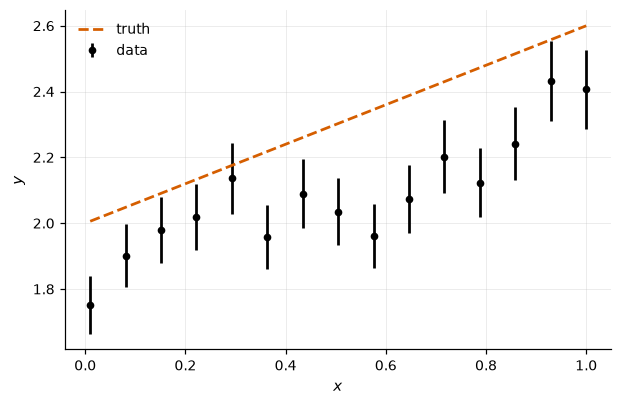

In [15]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.plot(x, y_true, "--", color=plotstyle.COLOURS[1], label="truth")
ax.set(xlabel="$x$", ylabel="$y$")
ax.legend()
plt.show()

## Setting up the model, prior, and experiment

We put the prior deliberately far from the truth, so that the data and not the prior decide where we end up.  Then we write three small helpers we will reuse on every rung: `fit` runs emcee on any problem, `band` pushes posterior rows through the model on a fine grid, and `summary` prints the columns by name. 

In [4]:
m = rx.Parameter("m", prior=stats.norm(2.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(5.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
x_fine = np.linspace(0.0, 1.0, 40)
comp = rx.Comparison(data, line)

In [5]:
def fit(problem, seed, n_walkers=24, n_steps=1800):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


def band(problem, samples, levels=(5, 95)):
    """The line's own band: how well each error model compares to the truth"""
    return rx.predictive.grid_draws(
        problem,
        line.bind(x_fine),
        x_fine,
        samples[::10],
        model_only=True,
        levels=levels,
    )


def summary(problem, samples):
    return "  ".join(
        f"{n} = {samples[:, i].mean():.3f} +/- {samples[:, i].std():.3f}"
        for i, n in enumerate(problem.names)
    )

## 1. Reported statistics only

The default covariance is the diagonal of `y_err`.  Nothing in it knows about
the normalisation, so we should expect a posterior that is precise and wrong —
the worst combination.

In [6]:
p_stat = rx.Problem([rx.Constraint([comp])])
s_stat = fit(p_stat, seed=1)
print(summary(p_stat, s_stat))

m = 0.483 +/- 0.087  b = 1.836 +/- 0.049


## 2. Inferring the noise level (recipe 2)

Suppose the experiment had not reported errors at all.  We can infer them:
`T.proportional_error` puts a free relative noise $\sigma_i = \epsilon\, y_{m,i}$
on the diagonal, sampled in log space, and `statistical=False` drops the
reported diagonal so the inferred one replaces it rather than piling on top of
it.  (`T.noise` is the constant-floor variant, $\sigma_i = \epsilon$.)

In [7]:
log_eps = rx.Parameter(
    "log_eps", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\epsilon"
)
p_noise = rx.Problem(
    [rx.Constraint([comp], terms=[T.proportional_error(log_eps)], statistical=False)]
)
s_noise = fit(p_noise, seed=2)
print(p_noise.names)
print(summary(p_noise, s_noise))
inferred = np.exp(s_noise[:, 2]).mean()
print(f"inferred noise fraction: {inferred:.3f}   (generated with {noise_fraction})")

['m', 'b', 'log_eps']
m = 0.531 +/- 0.277  b = 1.909 +/- 0.404  log_eps = -2.981 +/- 0.425
inferred noise fraction: 0.061   (generated with 0.05)


## 3. The reported systematic, as a correlated mode

If the experiment *had* reported a 10 % normalisation uncertainty, the honest
covariance adds a rank-one mode proportional to the prediction:

$$\Sigma_{ij} = \delta_{ij}\,\sigma_i^2 + (0.1)^2\, y_{m,i}\, y_{m,j}.$$

Because the mode reads $y_m$, the covariance changes with the parameters, and
`rxmc` reassembles it at every likelihood call.

In [8]:
p_norm = rx.Problem(
    [rx.Constraint([comp], terms=[T.normalization(magnitude=sys_fraction)])]
)
s_norm = fit(p_norm, seed=3)
print(summary(p_norm, s_norm))

m = 0.503 +/- 0.104  b = 1.917 +/- 0.220


## 4. The same mode built from the data: Peelle's Pertinent Puzzle

The tempting shortcut is to build that mode from the measured values,
$(0.1)^2 y_i y_j$, as a fixed matrix.  `rxmc` will let us: any symmetric block
is a term (recipe 19), so the mistake is easy to spell.

It is also the covariance behind [Peelle's Pertinent
Puzzle](https://en.wikipedia.org/wiki/Peelle%27s_Pertinent_Puzzle): the
fluctuations feed back into the covariance and pull the fit *below* the data.
[D'Agostini (1994)](https://doi.org/10.1016/0168-9002(94)90719-6) diagnosed it,
[Frühwirth, Neudecker & Leeb
(2012)](https://doi.org/10.1051/epjconf/20122700008) wrote out the solution, and
recipes 27 and 37 carry the closed forms.

In [9]:
wrong = rx.Term(sys_fraction**2 * np.outer(data.y, data.y), kind="matrix")
p_wrong = rx.Problem([rx.Constraint([comp], terms=[wrong])])
s_wrong = fit(p_wrong, seed=4)
print(summary(p_wrong, s_wrong))

m = 0.439 +/- 0.097  b = 1.680 +/- 0.184


### Four posteriors, one truth

In [10]:
runs = {
    "statistics only": (p_stat, s_stat, plotstyle.COLOURS[0], plotstyle.HATCHES[0]),
    "inferred noise": (p_noise, s_noise, plotstyle.COLOURS[2], plotstyle.HATCHES[1]),
    "mode from $y_m$": (p_norm, s_norm, plotstyle.COLOURS[4], plotstyle.HATCHES[2]),
    "mode from $y$ (Peelle)": (
        p_wrong,
        s_wrong,
        plotstyle.COLOURS[1],
        plotstyle.HATCHES[3],
    ),
}
bands = {label: band(p, s) for label, (p, s, _, _) in runs.items()}

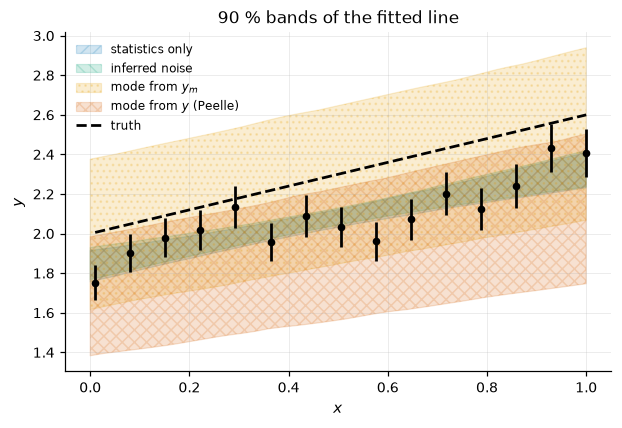

In [11]:
fig, ax = plt.subplots()
for label, (lo, hi) in bands.items():
    _, _, colour, hatch = runs[label]
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=label)
ax.plot(x, y_true, "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", ms=4)
ax.set(xlabel="$x$", ylabel="$y$", title="90 % bands of the fitted line")
ax.legend(fontsize=8)
plt.show()

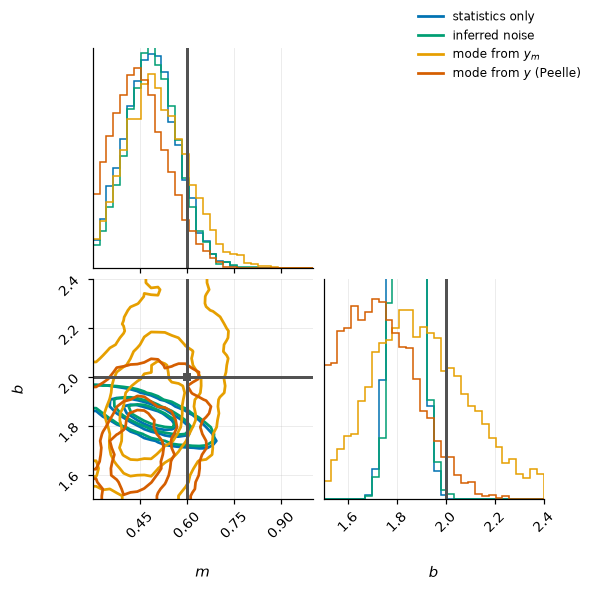

In [12]:
fig = None
for label, (p, s, colour, _) in runs.items():
    fig = corner.corner(
        s[:, p.columns(line.params)],
        fig=fig,
        labels=["$m$", "$b$"],
        truths=[truth["m"], truth["b"]],
        range=[(0.3, 1.0), (1.5, 2.4)],
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, label=lab) for lab, (_, _, c, _) in runs.items()
    ],
    loc="upper right",
    fontsize=8,
)
plt.show()

Statistics only is confidently wrong, inferring the noise *does* cover the data but not the true line. The systematic covariance built from the prediction covers the truth at an honest width, it is the only one of the four that knows the defect was a single number multiplying everything. And the Peelle covariance is the worst of all, biased below the data.